In [96]:
import copy
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [159]:
# set params
img_path = "../data/img_example.png"

In [160]:
def show_image(image:np.ndarray):
    plt.imshow(image)
    plt.title("example")
    plt.axis("off")
    plt.show()

In [161]:
def image_preprocessing(image:np.ndarray):
    
    orig_img = copy.deepcopy(image)
    
    img_hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    
    h, w = img_hsv.shape[:2]
    
    stripe_width = 10
    l_stripe = img_hsv[:, 0:stripe_width].reshape(-1, 3)
    r_stripe = img_hsv[:, w-stripe_width:w].reshape(-1, 3)
    up_stripe = img_hsv[0:stripe_width, :].reshape(-1, 3)
    bt_stripe = img_hsv[h-stripe_width:h, :].reshape(-1, 3)
    
    un_stripe = np.concatenate((l_stripe, r_stripe, up_stripe, bt_stripe), axis=0)
    
    # color statistics
    bg_median = np.median(un_stripe, axis=0)
    bg_std = np.std(un_stripe, axis=0)
    
    koef_tol = 3
    h_tol = max(10, koef_tol * bg_std[0])
    s_tol = max(20, koef_tol * bg_std[1])
    v_tol = max(20, koef_tol * bg_std[2])
    
    # thresholds
    tr_lower = np.array([
        max(0, bg_median[0] - h_tol),
        max(30, bg_median[1] - s_tol),
        max(30, bg_median[2] - v_tol)
    ], dtype=np.uint8)

    tr_upper = np.array([
        min(180, bg_median[0] + h_tol),
        min(255, bg_median[1] + s_tol),
        min(255, bg_median[2] + v_tol)
    ], dtype=np.uint8)
    
    bg_mask = cv2.inRange(img_hsv, tr_lower, tr_upper)
    item_mask = cv2.bitwise_not(bg_mask)
    
    kernelSize = (9, 9)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, kernelSize)
    
    item_mask = cv2.morphologyEx(
        item_mask, cv2.MORPH_CLOSE, kernel, iterations=1,
    )
    # item_mask = cv2.morphologyEx(item_mask, cv2.MORPH_OPEN, kernel, iterations=1)
    
    # print(img_hue.shape)

    contours, _ = cv2.findContours(
        item_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE
    )
    
    if len(contours) == 0:
        print("No contours found!")
        return orig_img
    
    max_area = 0
    biggest_cont = None
    
    print(len(contours))
    
    for cnt in contours:
        area = cv2.contourArea(contour=cnt)
        # print(f"contour area: {area}")
        if area > max_area:
            max_area = area
            biggest_cont = cnt
            
    print(f"max area: {max_area}")
            
    # cont_len = cv2.arcLength(biggest_cont, True)
    approx = cv2.approxPolyDP(biggest_cont, 0.5, True)
    
    approx = approx.astype(np.int32)
    
    # cv2.drawContours(orig_img, [biggest_cont], -1, (0, 255, 0), 3)
    cv2.drawContours(orig_img, [approx], -1, (0, 255, 0), 3)
    show_image(orig_img)
    
    print(f"approx len: {len(approx)}")
    
    # print(biggest_cont)
    
    return approx

24
max area: 498375.5


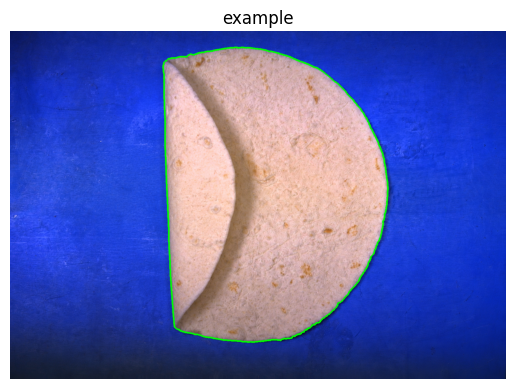

approx len: 497
497


In [162]:
# image = cv2.imread(img_path)

image = cv2.imdecode(
    np.fromfile(img_path, dtype=np.uint8),
    cv2.IMREAD_COLOR
)

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
biggest_cont = image_preprocessing(image)
print(len(biggest_cont))

In [163]:
# find straight line


def find_max_straight_edge_length(image, contour, curvature_threshold_px):
    Pnts = contour.reshape(-1, 2)
    print(Pnts.shape)
    
    num_pts = len(Pnts)
    
    if num_pts < 2:
        return 0.0
    
    # expand contour to handle wrap-around
    Pnts_exp = np.concatenate((Pnts, Pnts), axis=0)
    print(Pnts_exp.shape)
    
    straight_length = 0.0
    
    for i in range(num_pts):
        for j in range(i+1, i+num_pts):
            A_pt = Pnts_exp[i]
            B_pt = Pnts_exp[j]
            
            AB_v = B_pt - A_pt
            
            dx = B_pt[0] - A_pt[0]
            dy = B_pt[1] - A_pt[1]
            AB_len = (dx**2 + dy**2)**0.5
            
            if AB_len == 0 or AB_len <= straight_length:
                continue
            
            if j == i + 1:
                straight_length = AB_len
                continue
            
            # Int_Pts = Pnts_exp[i+1:j]
            # AC_v = Int_Pts - A_pt
            
            # cross_mult = np.cross(AB_v, AC_v)
            # dist = np.abs(cross_mult) / AB_len
            
            # if np.max(dist) <= curvature_threshold_px:
            #     straight_length = AB_len
            
            straight_flag = True
            for k in range(i+1, j):
                C_pt = Pnts_exp[k]
                
                sq_par = abs(dx*(C_pt[1] - A_pt[1]) - dy * (C_pt[0] - A_pt[0]))
                dist = sq_par / AB_len
                
                if dist > curvature_threshold_px:
                    straight_flag = False
                    break
                
            if straight_flag:
                straight_length = AB_len
                
    return straight_length

In [164]:
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
straight_length = find_max_straight_edge_length(
    image, biggest_cont, 10
)

print(f"max straight edge length: {straight_length:.2f} px")

(497, 2)
(994, 2)
max straight edge length: 800.68 px
